In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [225]:
def BBM3(S = None, N = 10, T = 20):
    if S == None:
        S = lambda x, y: 4
        
    h = 1. / ( N - 1 )
    
    mesh_x_y = np.empty( ( N * N, N * N ) )
    b = np.empty( N * N )
    
    for i in range(N):
        for j in range(N):
            if ( i == 0 ) | ( i == N - 1 ) | ( j == 0 ) | ( j == N - 1 ):
                mesh_x_y[i * N + j, :] = np.zeros( N * N )
                mesh_x_y[i * N + j, i * N + j] = 1
                b[i * N + j] = (lambda i, j: ( i * h ) ** 2 + ( j * h ) ** 2)( i, j )
            else:
                mesh_x_y[i * N + j, :] = np.zeros( N * N )
                
                mesh_x_y[i * N + j, i * N + j] = -4
                mesh_x_y[i * N + j, i * N + j + 1] = 1
                mesh_x_y[i * N + j, i * N + j - 1] = 1
                mesh_x_y[i * N + j, ( i + 1 ) * N + j] = 1
                mesh_x_y[i * N + j, ( i - 1 ) * N + j] = 1
                
                b[i * N + j] = S( i * h, j * h ) * (h ** 2)

    L = np.tril( mesh_x_y, k = -1 )
    R = np.triu( mesh_x_y, k = 1 )
    D = np.diag( np.diag( mesh_x_y ) )

    L = np.matrix(L)
    R = np.matrix(R)
    D = np.matrix(D)
    
    mesh = np.empty( ( T, N * N) )
    mesh[0, :] = 1

    for i in range(1, T):
        mesh[i, :] = ( -1 * D.getI() * ( ( L + R ) * mesh[i - 1, :].reshape( N * N, 1 ) - b.reshape( N * N, 1 ) ) ).reshape( N * N )
    
    return mesh

In [226]:
N = 10
T = 200
mesh = BBM3(N = N, T = T)

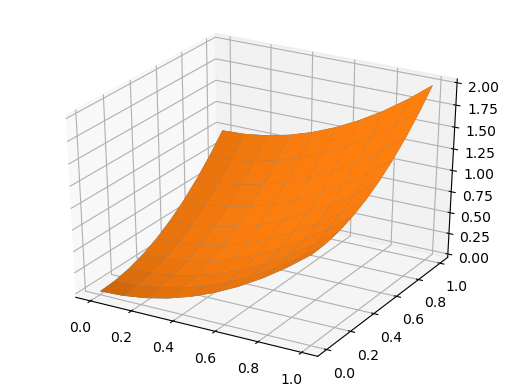

In [228]:
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

axis_x , axis_y = np.meshgrid( np.linspace(0, 1, N), np.linspace(0, 1, N) )

#for i in range(T):
#    ax.plot_surface(axis_x, axis_y, mesh[i, :].reshape(N, N))
ax.plot_surface(axis_x, axis_y, mesh[T-1, :].reshape(N, N))
ax.plot_surface(axis_x, axis_y, np.array( [[ (lambda i, j: ( i ) ** 2 + ( j ) ** 2)(x, y) for x in np.linspace(0, 1, N)] for y in np.linspace(0, 1, N)]))
plt.show()

f - точное решение выбрано x**2 + y**2, S = 4 в каждой точке соответсвенно


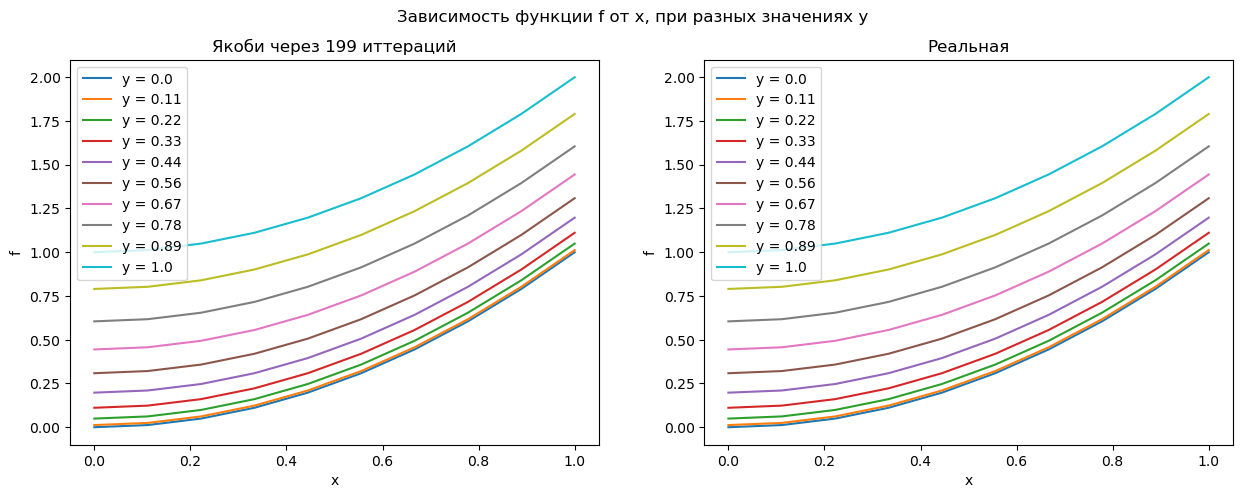

In [236]:
print('f - точное решение выбрано x**2 + y**2, S = 4 в каждой точке соответсвенно')
fig, axs = plt.subplots(1, 2, figsize=( 15, 5 ))
plt.suptitle(f'Зависимость функции f от x, при разных значениях y')
    
axs[0].plot(np.linspace(0, 1, N), mesh[T-1, :].reshape(N, N))
axs[0].legend( [f'y = {round(y, 2)}' for y in np.linspace(0, 1, N)] )
axs[0].set_title(f"Якоби через {T-1} иттераций")
axs[0].set_xlabel('x')
axs[0].set_ylabel('f')

axs[1].plot(np.linspace(0, 1, N), [[ (lambda i, j: ( i ) ** 2 + ( j ) ** 2)(x, y) for x in np.linspace(0, 1, N)] for y in np.linspace(0, 1, N)])
axs[1].legend( [f'y = {round(y, 2)}' for y in np.linspace(0, 1, N)] )
axs[1].set_title(f"Реальная")
axs[1].set_xlabel('x')
axs[1].set_ylabel('f')
plt.show()